In [60]:
import jax.numpy as jnp
from jax.scipy.linalg import solve
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator 
import numpy as np  
import torch

# Implicit method (4.2.5) 

In [61]:
# ---- Parameters ----

#method
V_MAX = 201
M = 1000
x_max = 3
x_min = -12

#option
option_type = "put"  # "put" or "call"
T = 1
K = 40

#stocks
r = 0.04
delta = 0.02
sigma = 0.4

In [62]:
# ---- Grid setup ----
x = jnp.linspace(x_min, x_max, V_MAX)
x_interior = x[1:-1]  # length V_MAX - 2

delta_x = (x_max - x_min) / (V_MAX - 1)
tau_max = 0.5 * sigma**2 * T
delta_tau = tau_max / (M - 1)
lamb = delta_tau / (delta_x ** 2)

In [63]:
# ---- Initial condition w(x, 0) ----
q_delta = 2 * (r - delta) / (sigma ** 2)

if option_type == "call":
    initial = jnp.maximum(
        jnp.exp(0.5 * x_interior * (q_delta + 1)) - jnp.exp(0.5 * x_interior * (q_delta - 1)),
        0
    )
else:  # put
    initial = jnp.maximum(
        jnp.exp(0.5 * x_interior * (q_delta - 1)) - jnp.exp(0.5 * x_interior * (q_delta + 1)),
        0
    )

w = jnp.zeros((V_MAX - 2, M))
w = w.at[:, 0].set(initial)


In [64]:
# ---- Construct A matrix - equation (4.18) ----
diag_main = (1 + 2 * lamb) * jnp.ones(V_MAX - 2)
diag_off = -lamb * jnp.ones(V_MAX - 3)
A = jnp.diag(diag_main) + jnp.diag(diag_off, 1) + jnp.diag(diag_off, -1)

In [65]:
# ---- Time stepping - equation (4.19) ----
def step_fn(w_nu):
    return solve(A, w_nu, assume_a='pos') #solve the linear system of equations

for nu in range(M - 1):
    w = w.at[:, nu + 1].set(step_fn(w[:, nu]))

In [66]:
# ---- Undo transformation to pass from w(x,tau) to v(x, tau) - equation (4.3)----
tau = jnp.linspace(0, tau_max, M)
q = 2 * r / sigma**2
factor = jnp.exp(
    -0.5 * (q_delta - 1) * x_interior[:, None] -
    (0.25 * (q_delta - 1)**2 + q) * tau[None, :]
)
v = K * factor * w

In [67]:
# ---- Interpolation and change of variables from v(x, tau) to V(S, t) ----
v_np = np.array(v)
x_np = np.array(x_interior)
tau_np = np.array(tau)
v_interp = RegularGridInterpolator((x_np, tau_np), v_np, bounds_error=False, fill_value=None)

def V(S, t):
    x_val = np.log(S / K)
    tau_val = 0.5 * sigma**2 * (T - t)
    return v_interp([x_val, tau_val])

## Debug

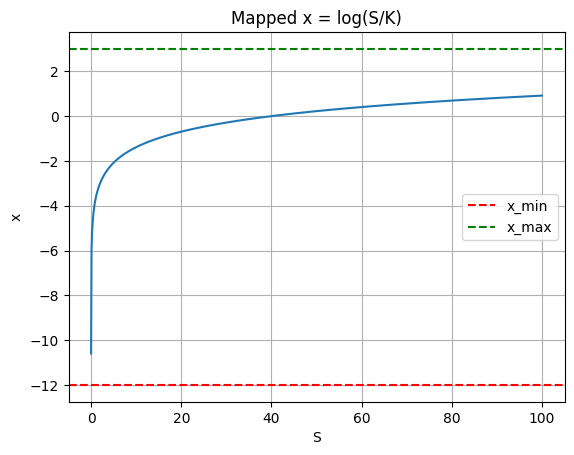

In [68]:
S_vals = np.linspace(1e-3, 100, 1000)
x_vals = np.log(S_vals / K)
plt.plot(S_vals, x_vals)
plt.axhline(x_min, color='r', linestyle='--', label='x_min')
plt.axhline(x_max, color='g', linestyle='--', label='x_max')
plt.legend()
plt.title("Mapped x = log(S/K)")
plt.xlabel("S")
plt.ylabel("x")
plt.grid()
plt.show()


## Visualization

C:\Users\matze\AppData\Local\Temp\ipykernel_23076\2373621669.py:8: RuntimeWarning: divide by zero encountered in log
  x_val = np.log(S / K)


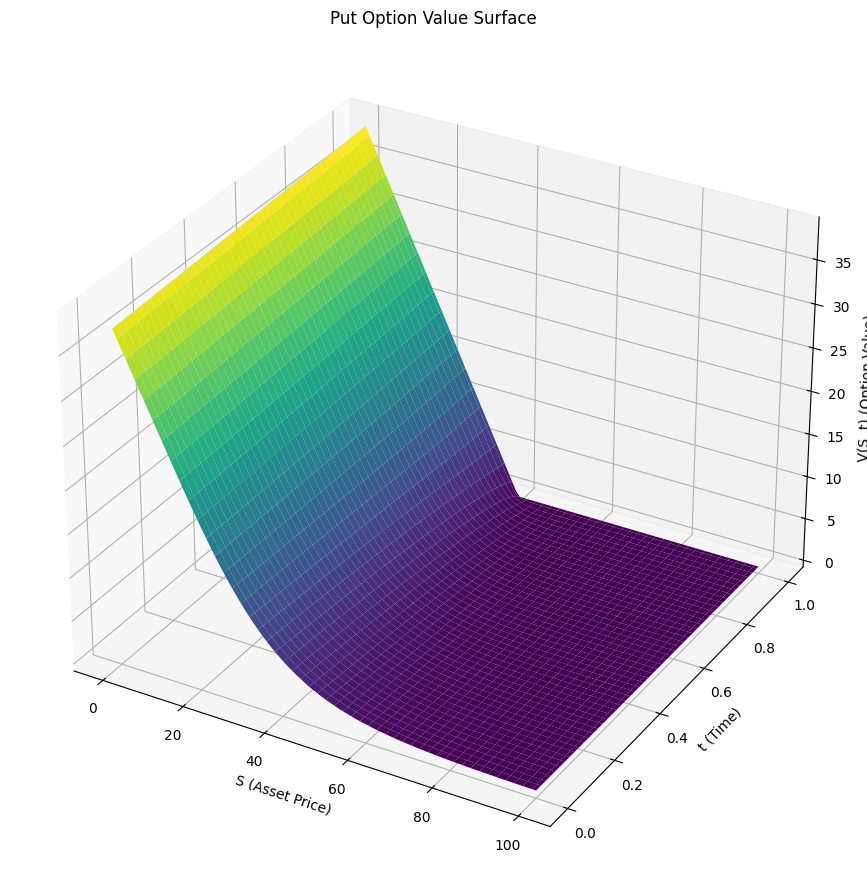

In [69]:
S_vals = np.linspace(0, 100, 100)
t_vals = np.linspace(0, T, 100)
S_grid, t_grid = np.meshgrid(S_vals, t_vals)
V_func = np.vectorize(V)
V_grid = V_func(S_grid, t_grid)

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, t_grid, V_grid, cmap='viridis')
ax.set_xlabel('S (Asset Price)')
ax.set_ylabel('t (Time)')
ax.set_zlabel('V(S, t) (Option Value)')
ax.set_title(f"{option_type.capitalize()} Option Value Surface")
plt.tight_layout()
plt.show()


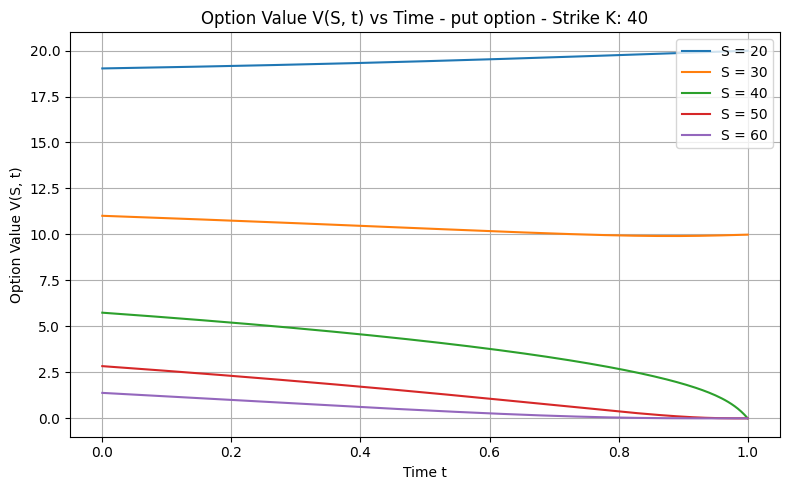

In [70]:
def plot_V_over_time(S_list):
    t_vals = np.linspace(0, T, 200)
    plt.figure(figsize=(8, 5))
    for S in S_list:
        values = [V(S, t) for t in t_vals]
        plt.plot(t_vals, values, label=f"S = {S}")
    plt.title(f"Option Value V(S, t) vs Time - {option_type} option - Strike K: {K}")
    plt.xlabel("Time t")
    plt.ylabel("Option Value V(S, t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_V_over_time([20, 30, 40, 50, 60])


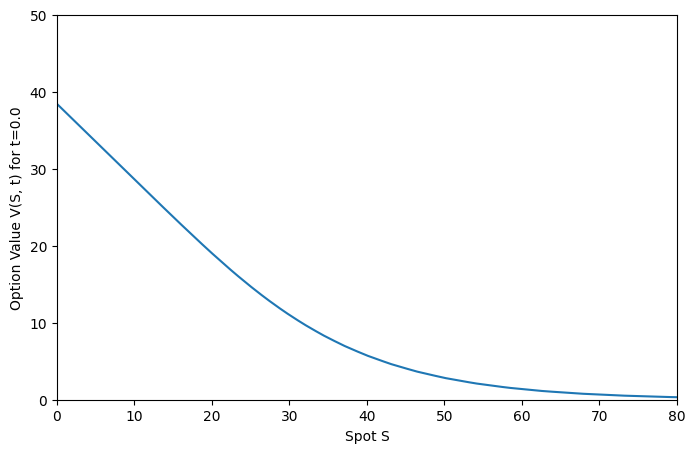

In [71]:
plt.figure(figsize=(8, 5))
t = 0.0
S_vals = np.linspace(0.01, 100, 300)
values = [V(S, t) for S in S_vals]
plt.plot(S_vals, values)
plt.xlabel("Spot S")
plt.ylabel("Option Value V(S, t) for t=0.0")
plt.xlim(0, 80)
plt.ylim(0, 50)
plt. show()

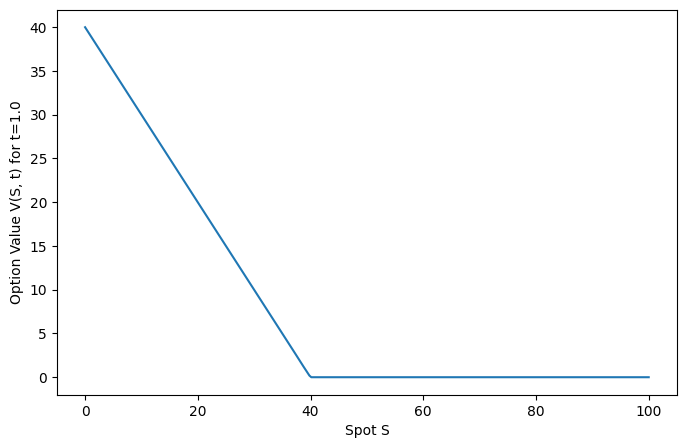

In [72]:
plt.figure(figsize=(8, 5))
t = 1.0
S_vals = np.linspace(0.01, 100, 300)
values = [V(S, t) for S in S_vals]
plt.plot(S_vals, values)
plt.xlabel("Spot S")
plt.ylabel("Option Value V(S, t) for t=1.0")
plt. show()

## Stopping Boundary

In [73]:
def payoff(S):
    if option_type == "put":
        return max(K - S, 0)
    else:  # call
        return max(S - K, 0)

C:\Users\matze\AppData\Local\Temp\ipykernel_23076\2373621669.py:8: RuntimeWarning: divide by zero encountered in log
  x_val = np.log(S / K)


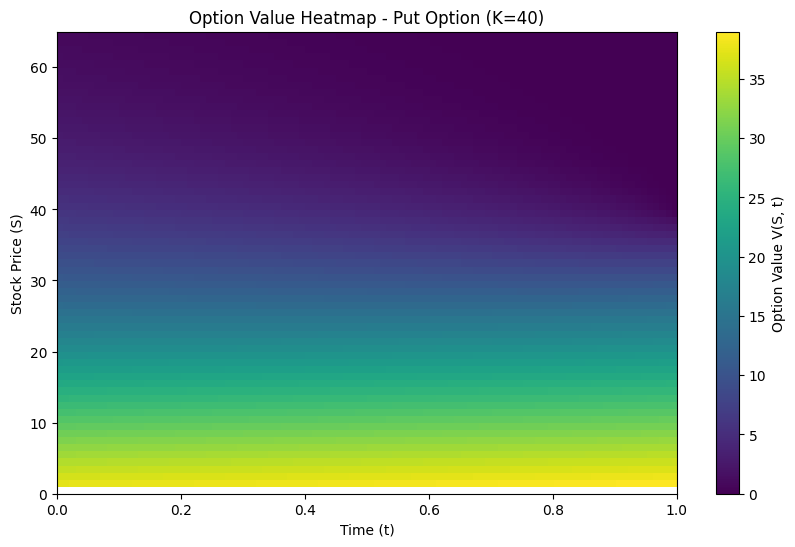

In [74]:
### Value Heatmap ###

# Compute V(t, S) over the grid
V_func_invert = np.vectorize(lambda t, s: V(s, t))  # swap order in lambda
V_grid = V_func_invert(t_grid, S_grid)              # t first, then s
V_grid = V_grid.T                            # transpose to match axis orientation

# Plot with time on x-axis and stock price on y-axis
plt.figure(figsize=(10, 6))
plt.imshow(
    V_grid,
    extent=(t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()),  # time on x, stock on y
    aspect='auto',
    cmap='viridis',
    origin='lower' 
)
plt.colorbar(label='Option Value V(S, t)')
plt.title(f"Option Value Heatmap - {option_type.capitalize()} Option (K={K})")
plt.xlabel("Time (t)")
plt.ylabel("Stock Price (S)")
plt.ylim(0, 65)
plt.show()


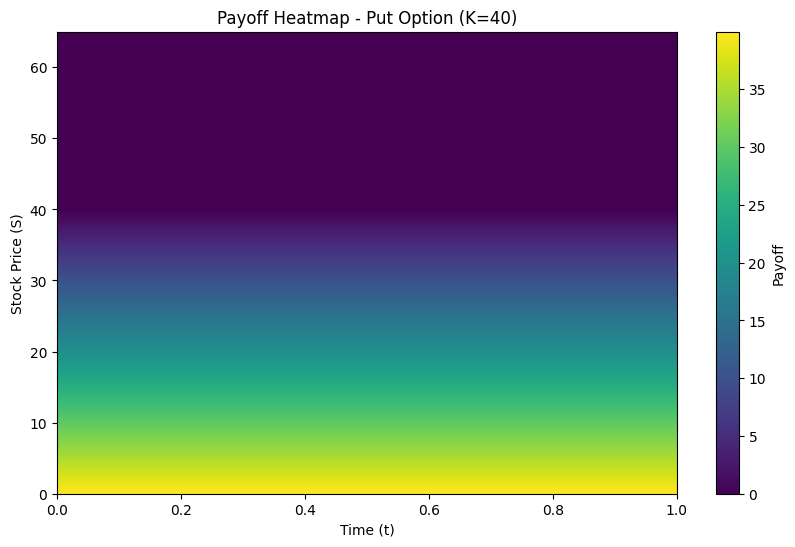

In [75]:
### Payoff Heatmap ###

payoff_1d = np.array([payoff(S) for S in S_vals])  # shape (len(S_vals),)

# Repeat across time axis to make a 2D grid
payoff_grid = np.tile(payoff_1d[:, np.newaxis], (1, len(t_vals)))  # shape (len(S_vals), len(t_vals))

# Plot the heatmap
plt.figure(figsize=(10, 6))
plt.imshow(
    payoff_grid,
    extent=(t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()),  # t on x, S on y
    aspect='auto',
    cmap='viridis',
    origin='lower'
)
plt.colorbar(label='Payoff')
plt.title(f"Payoff Heatmap - {option_type.capitalize()} Option (K={K})")
plt.xlabel("Time (t)")
plt.ylabel("Stock Price (S)")
plt.ylim(0, 65)
plt.show()


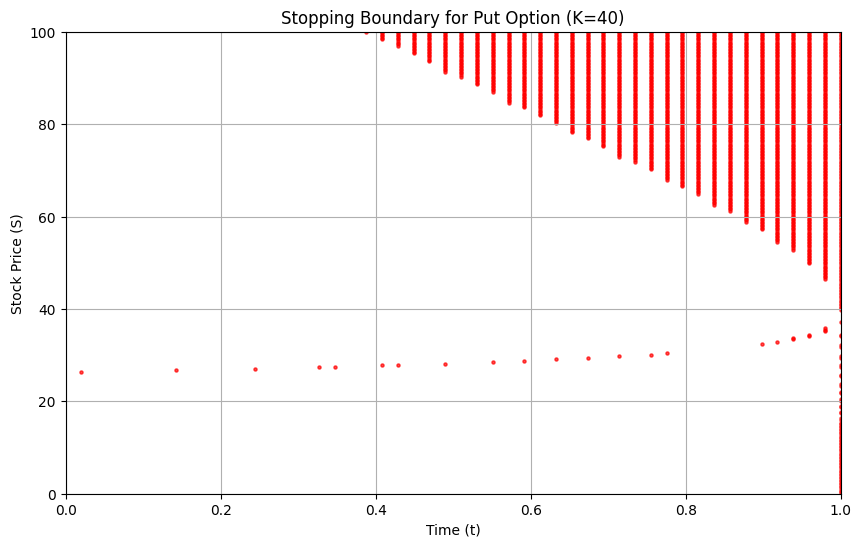

In [76]:
#plot the stopping boundary

#stopping boundary is where the option value at time t is equal to the payoff at time t
#for this implementation, the stopping boundary is defined as the point where |V(S, t) - g(S)| < threshold
#to implement this, we go over the grid of V(S, t) and find the points where the condition is satisfied and scatter them on a plot

# Plot stopping boundary over time
t_values = np.linspace(0, T, 50)  # 50 time points
S_values = np.linspace(0.01, 100, 300)  # 300 stock price points
stopping_points = []

# Find stopping boundary for each time point
for t in t_values:
    for S in S_values:
        option_value = V(S, t)
        payoff_value = payoff(S)
        if abs(option_value - payoff_value) < 1e-2:
            stopping_points.append((S, t))

# Extract coordinates for plotting
S_coords = [point[0] for point in stopping_points]
t_coords = [point[1] for point in stopping_points]

plt.figure(figsize=(10, 6))
plt.scatter(t_coords, S_coords, color='red', s=5, alpha=0.7)
plt.title(f"Stopping Boundary for {option_type.capitalize()} Option (K={K})")
plt.ylabel("Stock Price (S)")
plt.xlabel("Time (t)")
plt.grid(True)
plt.xlim(0, T)
plt.ylim(0, 100)
plt.show()


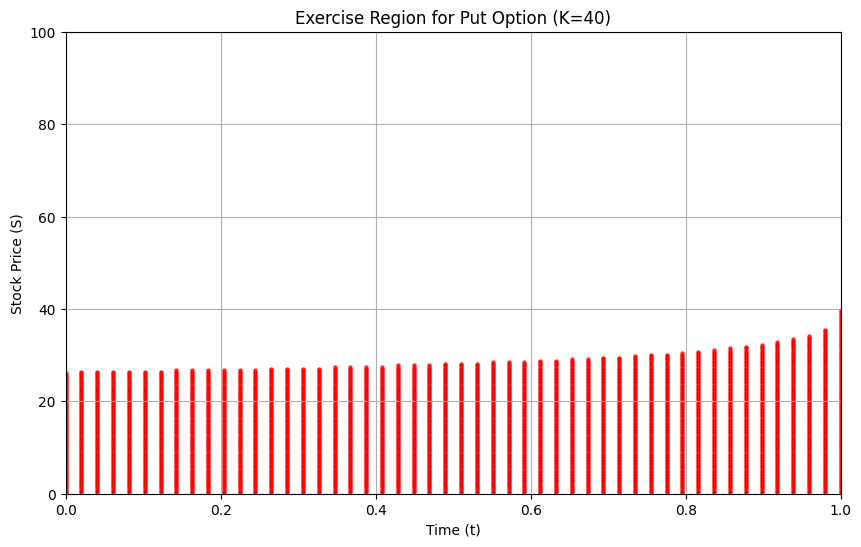

In [77]:
def payoff(S):
    if option_type == "put":
        return max(K - S, 0)
    else:  # call
        return max(S - K, 0)

# Parameters
t_values = np.linspace(0, T, 50)     
S_values = np.linspace(0.01, 100, 300)   
exercise_points = []

# Find points where payoff > option value (exercise region)
for t in t_values:
    for S in S_values:
        option_value = V(S, t)
        payoff_value = payoff(S)
        if payoff_value > option_value:
            exercise_points.append((S, t))

# Extract coordinates for scatter plot
S_coords = [point[0] for point in exercise_points]
t_coords = [point[1] for point in exercise_points]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(t_coords, S_coords, color='red', s=5, alpha=0.7)
plt.title(f"Exercise Region for {option_type.capitalize()} Option (K={K})")
plt.xlabel("Time (t)")
plt.ylabel("Stock Price (S)")
plt.grid(True)
plt.xlim(0, T)
plt.ylim(0, 100)
plt.show()


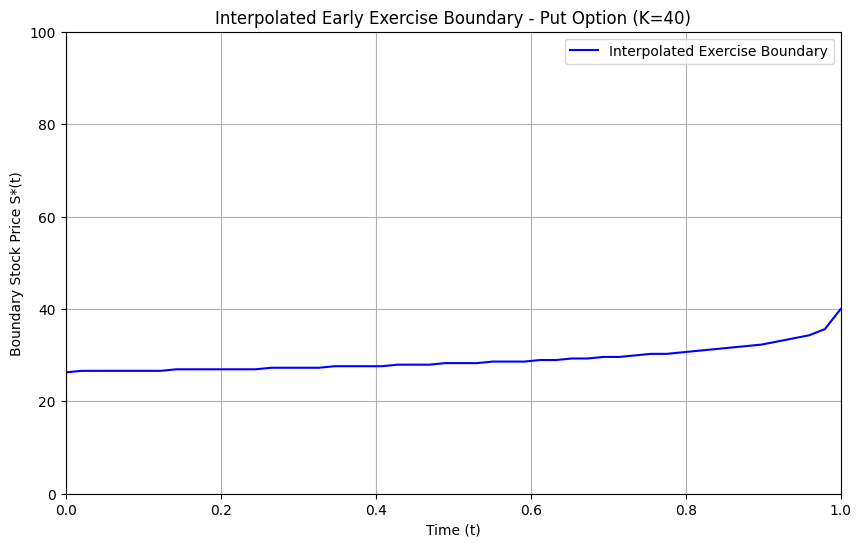

In [ ]:
"""
Compute the interpolated early exercise boundary for an American option

For each time step t, we scan over the stock prices S to detect the transition
point between the continuation region (where the option value V(S, t) > payoff(S))
and the exercise region (where payoff(S) > V(S, t)).

The boundary is defined as the first crossing point (S*) where this switch occurs.
To improve precision, we estimate S* as the midpoint between the last stock price
where V > payoff and the first one where V <= payoff.

For put options, early exercise typically occurs at low S, so we scan S in reverse.
For call options, we scan from low to high.

The result is a list of (t, S*) points that define the early exercise boundary,
which can be plotted as a curve S*(t).
"""

t_values = np.linspace(0, T, 50)
S_values = np.linspace(0.01, 100, 300)
boundary = []

for t in t_values:
    prev_V, prev_g, prev_S = None, None, None
    boundary_S = None

    # For put: exercise region is at low: scan from high to low
    if option_type == "put":
        S_iter = reversed(S_values)
    else:
        S_iter = S_values  # call: exercise region is at high S

    for S in S_iter:
        V_val = V(S, t)
        g_val = payoff(S)

        if prev_V is not None:
            if prev_V > prev_g and V_val <= g_val:
                boundary_S = 0.5 * (prev_S + S)
                break

        prev_V, prev_g, prev_S = V_val, g_val, S

    if boundary_S is not None:
        boundary.append((t, boundary_S))

# Extract
t_boundary = [b[0] for b in boundary]
S_boundary = [b[1] for b in boundary]


# Plot
plt.figure(figsize=(10, 6))
plt.plot(t_boundary, S_boundary, color='blue', label='Interpolated Exercise Boundary')
plt.title(f"Interpolated Early Exercise Boundary - {option_type.capitalize()} Option (K={K})")
plt.xlabel("Time (t)")
plt.ylabel("Boundary Stock Price S*(t)")
plt.grid(True)
plt.xlim(0, T)
plt.ylim(0, 100)
plt.legend()
plt.show()


In [83]:
# -----------------------------------------------------
# Simulate paths under Black-Scholes dynamics
# -----------------------------------------------------
# Define time grid for simulation
t_grid = np.linspace(0, T, 50) #Bermudan option so the price depends on the nb of time steps
dt = t_grid[1] - t_grid[0]  # Time step size

def simulate_paths(B, lambd=0):
    """
    Simulates B paths of the underlying asset price using the Black-Scholes model.

    Args:
        B: Number of paths to simulate
        lambd: Importance sampling parameter (not used here)

    Returns:
        S: Simulated paths, shape (B, len(t_grid), 1)
        Z: Dummy Radon-Nikodym derivatives (all ones)
    """
    S = np.zeros((B, len(t_grid), 1), dtype=np.float32)
    S[:, 0, 0] = K  # Start at the strike price (could also be S0)

    for i in range(len(t_grid) - 1):
        z = np.random.randn(B)
        S[:, i + 1, 0] = S[:, i, 0] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)

    Z = torch.ones((B, len(t_grid)), dtype=torch.float32)  # For consistency with importance sampling
    return S, Z

# -----------------------------------------------------
# Compute price from early exercise boundary
# -----------------------------------------------------
def compute_price_from_boundary(t_boundary, S_boundary, simulated_paths, K):
    """
    Compute the price of an American option using a precomputed early exercise boundary.

    Args:
        t_boundary: 1D numpy array of time values (shape: [T_steps])
        S_boundary: 1D numpy array of corresponding boundary stock prices (shape: [T_steps])
        simulated_paths: Tuple containing (paths, Z)
        K: Strike price

    Returns:
        Estimated option price
    """
    paths, _ = simulated_paths

    if isinstance(paths, torch.Tensor):
        paths = paths.numpy()

    # Interpolate stopping boundary
    boundary_fn = lambda t: np.interp(t, t_boundary, S_boundary)
    option_values = np.zeros(paths.shape[0])

    for path_idx in range(paths.shape[0]):
        stopped = False
        for time_idx, t in enumerate(t_boundary):
            stock_price = paths[path_idx, time_idx, 0]
            boundary_price = boundary_fn(t)

            if stock_price <= boundary_price:
                payoff = max(K - stock_price, 0)
                option_values[path_idx] = payoff * np.exp(-r * t)
                stopped = True
                break

        if not stopped:
            final_price = paths[path_idx, -1, 0]
            final_payoff = max(K - final_price, 0)
            option_values[path_idx] = final_payoff * np.exp(-r * t_boundary[-1])

    return np.mean(option_values)


# -------------------------
# Run and print a single result
# -------------------------
# paths = simulate_paths(100000)
# price = compute_price_from_boundary(t_boundary, S_boundary, paths, K)
# print(f"Option price using precomputed boundary: {price:.4f}")

# Compute multiple runs to estimate price stability
num_runs = 10
num_paths_price_eval = 100000
prices = []

print(f"\nRunning {num_runs} simulations with {num_paths_price_eval} paths each...")

for i in range(num_runs):
    paths = simulate_paths(num_paths_price_eval)
    price = compute_price_from_boundary(t_boundary, S_boundary, paths, K)
    prices.append(price)
    print(f"Run {i+1}: {price:.4f}")

mean_price = np.mean(prices)
std_price = np.std(prices)

print(f"\nStatistics over {num_runs} runs:")
print(f"Mean price: {mean_price:.4f}")
print(f"Standard deviation: {std_price:.4f}")
print(f"95% confidence interval: [{mean_price - 1.96*std_price/np.sqrt(num_runs):.4f}, {mean_price + 1.96*std_price/np.sqrt(num_runs):.4f}]")



Running 10 simulations with 100000 paths each...
Run 1: 5.5773
Run 2: 5.6004
Run 3: 5.6162
Run 4: 5.5749
Run 5: 5.5840
Run 6: 5.5836
Run 7: 5.5987
Run 8: 5.5641
Run 9: 5.6105
Run 10: 5.5991

Statistics over 10 runs:
Mean price: 5.5909
Standard deviation: 0.0158
95% confidence interval: [5.5811, 5.6007]
